# Summarize scGen latent-space clustering metrics

Reads per-seed clustering CSVs under:

`…/rebuttal_round2/test_scvi_scgen_evals_9_8_26/{species,pbmc,lps-hpoly}/clustering/`

Each file contains one row per **held-out group** (`test`) for a given **checkpoint** (`model` = AR or Naive) and **seed**.

Metrics: ARI, NMI, silhouette, Davies–Bouldin, Calinski–Harabasz.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RESULTS_ROOT = Path(
    "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/"
    "rebuttal_round2/test_scvi_scgen_evals_9_8_26"
)
DATASETS = ["species", "pbmc", "lps-hpoly"]
METRIC_COLS = [
    "ari",
    "nmi",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score",
]
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "eval_scripts" else NOTEBOOK_DIR
OUT_DIR = REPO_ROOT / "eval_scripts/outputs/scgen_latent_clustering_summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_ROOT:", RESULTS_ROOT)
print("OUT_DIR:", OUT_DIR)


RESULTS_ROOT: /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/test_scvi_scgen_evals_9_8_26
OUT_DIR: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries


## Load all clustering CSVs

In [16]:
def load_dataset_clustering(dataset: str, root: Path = RESULTS_ROOT) -> pd.DataFrame:
    cluster_dir = root / dataset / "clustering"
    if not cluster_dir.is_dir():
        raise FileNotFoundError(f"Missing clustering dir: {cluster_dir}")
    files = sorted(cluster_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs in {cluster_dir}")
    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["dataset"] = dataset
        df["source_file"] = path.name
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["seed"] = out["seed"].astype(int)
    out["model"] = out["model"].astype(str)
    out["test"] = out["test"].astype(str)
    return out


raw = pd.concat([load_dataset_clustering(ds) for ds in DATASETS], ignore_index=True)
print("rows:", len(raw))
print("files:", raw["source_file"].nunique())
print("coverage (dataset, model, seed):")
print(raw.groupby(["dataset", "model", "seed"]).size().unstack("seed", fill_value=0))
print("\nheld-out groups per dataset:")
for ds, sub in raw.groupby("dataset"):
    print(f"  {ds}: {sorted(sub['test'].unique())}")
raw.head()

rows: 190
files: 30
coverage (dataset, model, seed):
seed             100  101  102  103  104
dataset   model                         
lps-hpoly AR       8    8    8    8    8
          Naive    8    8    8    8    8
pbmc      AR       7    7    7    7    7
          Naive    7    7    7    7    7
species   AR       4    4    4    4    4
          Naive    4    4    4    4    4

held-out groups per dataset:
  lps-hpoly: ['Endocrine', 'Enterocyte', 'Enterocyte.Progenitor', 'Goblet', 'Stem', 'TA', 'TA.Early', 'Tuft']
  pbmc: ['B', 'CD14+Mono', 'CD4T', 'CD8T', 'Dendritic', 'FCGR3A+Mono', 'NK']
  species: ['mouse', 'pig', 'rabbit', 'rat']


,experiment_id,test,model,AR,variable_con,con_percent,in_dist_group,data_type,n_cells,n_clusters,ground_truth_label,silhouette_score,davies_bouldin_score,calinski_harabasz_score,ari,nmi,seed,kmeans_seed,dataset,source_file
0,species-oodTrue-variable_conFalse,mouse,AR,True,False,1.0,NaN,all,58802,4,species,0.3271,1.2829,13650.0636,0.9996,0.9990,100,100,species,species-oodTrue-variable_conFalse_AR_all_laten...
1,species-oodTrue-variable_conFalse,pig,AR,True,False,1.0,NaN,all,59101,4,species,0.3423,1.3047,13350.8790,0.9996,0.9990,100,100,species,species-oodTrue-variable_conFalse_AR_all_laten...
2,species-oodTrue-variable_conFalse,rabbit,AR,True,False,1.0,NaN,all,59969,4,species,0.3316,1.2841,13915.7978,0.9998,0.9995,100,100,species,species-oodTrue-variable_conFalse_AR_all_laten...
3,species-oodTrue-variable_conFalse,rat,AR,True,False,1.0,NaN,all,59997,4,species,0.3632,1.2806,15236.2861,0.9996,0.9988,100,100,species,species-oodTrue-variable_conFalse_AR_all_laten...
4,species-oodTrue-variable_conFalse,mouse,AR,True,False,1.0,NaN,all,58802,4,species,0.2964,1.3995,11943.4808,0.9995,0.9987,101,101,species,species-oodTrue-variable_conFalse_AR_all_laten...


## Per-dataset summary: mean ± std over seeds

Grouped by **held-out group** (`test`) and **checkpoint** (`model` = AR vs Naive).

In [17]:
def summarize_mean_std(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    agg = df.groupby(group_cols, dropna=False)[METRIC_COLS].agg(["mean", "std", "count"])
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    return agg.reset_index()


def format_mean_std(df: pd.DataFrame, metrics: list[str] | None = None) -> pd.DataFrame:
    """Pretty table with mean±std strings."""
    metrics = metrics or ["ari", "nmi", "silhouette_score"]
    id_cols = [c for c in df.columns if not any(c.endswith(sfx) for sfx in ("_mean", "_std", "_count"))]
    pretty = df[id_cols].copy()
    for m in metrics:
        mean_c, std_c = f"{m}_mean", f"{m}_std"
        if mean_c in df.columns:
            pretty[m] = [
                f"{mu:.3f}±{sd:.3f}" if pd.notna(sd) else f"{mu:.3f}"
                for mu, sd in zip(df[mean_c], df[std_c])
            ]
    if "ari_count" in df.columns:
        pretty["n_seeds"] = df["ari_count"].astype(int)
    return pretty


by_group = summarize_mean_std(raw, ["dataset", "model", "test", "ground_truth_label"])
by_group_path = OUT_DIR / "clustering_by_heldout_group.csv"
by_group.to_csv(by_group_path, index=False)
print("Saved:", by_group_path)

for ds in DATASETS:
    print("\n" + "=" * 72)
    print(f"Dataset: {ds}")
    print("=" * 72)
    sub = by_group[by_group["dataset"] == ds].copy()
    pretty = format_mean_std(sub, ["ari", "nmi", "silhouette_score", "davies_bouldin_score"])
    # Naive then AR within each held-out group for side-by-side comparison
    pretty["model"] = pd.Categorical(pretty["model"], categories=["Naive", "AR"], ordered=True)
    pretty = pretty.sort_values(["test", "model"]).reset_index(drop=True)
    display(pretty)


Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/clustering_by_heldout_group.csv

Dataset: species


,dataset,model,test,ground_truth_label,ari,nmi,silhouette_score,davies_bouldin_score,n_seeds
0,species,Naive,mouse,species,0.428±0.241,0.516±0.202,0.361±0.084,1.017±0.230,5
1,species,AR,mouse,species,0.999±0.000,0.998±0.001,0.310±0.016,1.354±0.059,5
2,species,Naive,pig,species,0.689±0.219,0.723±0.194,0.352±0.021,1.090±0.110,5
3,species,AR,pig,species,1.000±0.000,0.999±0.000,0.349±0.010,1.300±0.043,5
4,species,Naive,rabbit,species,0.357±0.138,0.422±0.184,0.326±0.069,1.139±0.275,5
5,species,AR,rabbit,species,1.000±0.000,1.000±0.000,0.339±0.014,1.277±0.040,5
6,species,Naive,rat,species,0.759±0.148,0.754±0.152,0.416±0.057,1.023±0.171,5
7,species,AR,rat,species,1.000±0.000,0.999±0.001,0.366±0.007,1.263±0.026,5



Dataset: pbmc


,dataset,model,test,ground_truth_label,ari,nmi,silhouette_score,davies_bouldin_score,n_seeds
0,pbmc,Naive,B,cell_type,0.509±0.110,0.573±0.066,0.218±0.050,1.596±0.283,5
1,pbmc,AR,B,cell_type,0.470±0.074,0.565±0.038,0.181±0.022,2.583±0.396,5
2,pbmc,Naive,CD14+Mono,cell_type,0.507±0.056,0.577±0.036,0.234±0.027,1.659±0.178,5
3,pbmc,AR,CD14+Mono,cell_type,0.471±0.018,0.562±0.018,0.198±0.011,2.921±0.085,5
4,pbmc,Naive,CD4T,cell_type,0.351±0.010,0.475±0.012,0.251±0.015,1.365±0.050,5
5,pbmc,AR,CD4T,cell_type,0.416±0.037,0.528±0.040,0.166±0.020,2.350±0.407,5
6,pbmc,Naive,CD8T,cell_type,0.493±0.059,0.578±0.016,0.208±0.031,1.671±0.184,5
7,pbmc,AR,CD8T,cell_type,0.422±0.005,0.555±0.004,0.160±0.011,2.822±0.064,5
8,pbmc,Naive,Dendritic,cell_type,0.458±0.078,0.560±0.035,0.202±0.023,1.716±0.150,5
9,pbmc,AR,Dendritic,cell_type,0.386±0.028,0.522±0.028,0.171±0.012,2.478±0.371,5



Dataset: lps-hpoly


,dataset,model,test,ground_truth_label,ari,nmi,silhouette_score,davies_bouldin_score,n_seeds
0,lps-hpoly,Naive,Endocrine,cell_label,0.341±0.029,0.563±0.024,0.234±0.023,1.192±0.080,5
1,lps-hpoly,AR,Endocrine,cell_label,0.393±0.049,0.576±0.016,0.138±0.011,1.886±0.040,5
2,lps-hpoly,Naive,Enterocyte,cell_label,0.375±0.030,0.589±0.035,0.263±0.044,1.196±0.098,5
3,lps-hpoly,AR,Enterocyte,cell_label,0.439±0.061,0.592±0.019,0.150±0.014,1.942±0.060,5
4,lps-hpoly,Naive,Enterocyte.Progenitor,cell_label,0.366±0.043,0.546±0.031,0.217±0.012,1.287±0.075,5
5,lps-hpoly,AR,Enterocyte.Progenitor,cell_label,0.366±0.049,0.545±0.024,0.139±0.018,1.941±0.086,5
6,lps-hpoly,Naive,Goblet,cell_label,0.373±0.029,0.574±0.029,0.250±0.038,1.238±0.121,5
7,lps-hpoly,AR,Goblet,cell_label,0.448±0.042,0.589±0.017,0.152±0.013,2.037±0.083,5
8,lps-hpoly,Naive,Stem,cell_label,0.460±0.017,0.584±0.018,0.213±0.016,1.294±0.069,5
9,lps-hpoly,AR,Stem,cell_label,0.461±0.064,0.590±0.036,0.150±0.010,1.948±0.053,5


## Per-seed ARI / NMI (Naive and AR side by side)

One row per held-out group × seed, with Naive and AR values in adjacent columns.


In [18]:
per_seed = raw[["dataset", "test", "model", "seed", "ari", "nmi"]].copy()
per_seed_wide = (
    per_seed.pivot_table(
        index=["dataset", "test", "seed"],
        columns="model",
        values=["ari", "nmi"],
        aggfunc="first",
    )
    .sort_index(axis=1, level=0)
)
# Flatten columns: Naive_ari, AR_ari, Naive_nmi, AR_nmi
per_seed_wide.columns = [f"{model}_{metric}" for metric, model in per_seed_wide.columns]
# Prefer Naive then AR for each metric
col_order = [
    c
    for metric in ("ari", "nmi")
    for model in ("Naive", "AR")
    for c in [f"{model}_{metric}"]
    if c in per_seed_wide.columns
]
per_seed_wide = per_seed_wide[col_order].reset_index().sort_values(["dataset", "test", "seed"])

per_seed_path = OUT_DIR / "clustering_ari_nmi_per_seed.csv"
per_seed_wide.to_csv(per_seed_path, index=False)
print("Saved:", per_seed_path)

for ds in DATASETS:
    print("\n" + "=" * 72)
    print(f"Per-seed ARI / NMI | {ds}")
    print("=" * 72)
    sub = per_seed_wide[per_seed_wide["dataset"] == ds].drop(columns=["dataset"]).copy()
    # round for display
    for c in col_order:
        sub[c] = sub[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
    display(sub.reset_index(drop=True))


Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/clustering_ari_nmi_per_seed.csv

Per-seed ARI / NMI | species


,test,seed,Naive_ari,AR_ari,Naive_nmi,AR_nmi
0,mouse,100,0.3533,0.9996,0.4469,0.9990
1,mouse,101,0.8177,0.9995,0.8007,0.9987
2,mouse,102,0.3087,0.9996,0.5129,0.9989
3,mouse,103,0.4739,0.9985,0.5739,0.9967
4,mouse,104,0.1844,0.9994,0.2445,0.9985
5,pig,100,0.7115,0.9996,0.7253,0.9990
6,pig,101,0.9739,0.9998,0.9561,0.9993
7,pig,102,0.6889,0.9999,0.7851,0.9996
8,pig,103,0.7109,0.9998,0.7272,0.9994
9,pig,104,0.3590,0.9997,0.4202,0.9990



Per-seed ARI / NMI | pbmc


,test,seed,Naive_ari,AR_ari,Naive_nmi,AR_nmi
0,B,100,0.3930,0.3958,0.5070,0.5117
1,B,101,0.6066,0.4585,0.6392,0.5681
2,B,102,0.5798,0.4426,0.6078,0.5596
3,B,103,0.3854,0.5935,0.4981,0.6180
4,B,104,0.5825,0.4613,0.6137,0.5687
5,CD14+Mono,100,0.4902,0.4841,0.5837,0.5765
6,CD14+Mono,101,0.5803,0.4498,0.6251,0.5395
7,CD14+Mono,102,0.4365,0.4817,0.5234,0.5723
8,CD14+Mono,103,0.5436,0.4848,0.5739,0.5761
9,CD14+Mono,104,0.4862,0.4531,0.5803,0.5451



Per-seed ARI / NMI | lps-hpoly


,test,seed,Naive_ari,AR_ari,Naive_nmi,AR_nmi
0,Endocrine,100,0.3274,0.3632,0.5590,0.5602
1,Endocrine,101,0.3047,0.3873,0.5346,0.5738
2,Endocrine,102,0.3372,0.4095,0.5495,0.5814
3,Endocrine,103,0.3843,0.4667,0.5953,0.5998
4,Endocrine,104,0.3496,0.3384,0.5785,0.5623
5,Enterocyte,100,0.3388,0.3865,0.5422,0.5721
6,Enterocyte,101,0.4037,0.3973,0.6296,0.5840
7,Enterocyte,102,0.3478,0.4780,0.5704,0.5949
8,Enterocyte,103,0.3861,0.4072,0.6146,0.5881
9,Enterocyte,104,0.3974,0.5265,0.5880,0.6231


## Overall per checkpoint (averaged over held-out groups and seeds)

One row per dataset × model: mean ± std of metrics across all held-out groups and seeds.

In [19]:
by_model = summarize_mean_std(raw, ["dataset", "model", "ground_truth_label"])
by_model_path = OUT_DIR / "clustering_by_model.csv"
by_model.to_csv(by_model_path, index=False)
print("Saved:", by_model_path)
display(format_mean_std(by_model, METRIC_COLS).sort_values(["dataset", "model"]))

Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/clustering_by_model.csv


,dataset,model,ground_truth_label,ari,nmi,silhouette_score,davies_bouldin_score,calinski_harabasz_score,n_seeds
0,lps-hpoly,AR,cell_label,0.411±0.059,0.574±0.027,0.143±0.013,1.952±0.085,413.188±42.648,40
1,lps-hpoly,Naive,cell_label,0.364±0.052,0.563±0.036,0.229±0.033,1.246±0.085,1699.237±304.016,40
2,pbmc,AR,cell_type,0.427±0.053,0.545±0.033,0.175±0.021,2.622±0.362,1289.438±328.034,35
3,pbmc,Naive,cell_type,0.470±0.090,0.557±0.055,0.224±0.032,1.606±0.192,3784.416±1206.033,35
4,species,AR,species,1.000±0.000,0.999±0.001,0.341±0.024,1.298±0.054,14770.572±1968.354,20
5,species,Naive,species,0.558±0.247,0.604±0.221,0.364±0.067,1.067±0.196,38000.309±21884.333,20


## AR − Naive gap per held-out group (mean over seeds)

In [20]:
seed_means = (
    raw.groupby(["dataset", "model", "test", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)
wide = seed_means.pivot_table(
    index=["dataset", "test", "seed"],
    columns="model",
    values=METRIC_COLS,
)
# columns are MultiIndex (metric, model)
gaps = []
for metric in METRIC_COLS:
    if (metric, "AR") not in wide.columns or (metric, "Naive") not in wide.columns:
        continue
    gap = wide[(metric, "AR")] - wide[(metric, "Naive")]
    gaps.append(gap.rename(f"{metric}_AR_minus_Naive"))
gap_df = pd.concat(gaps, axis=1).reset_index()

gap_summary = (
    gap_df.groupby(["dataset", "test"], as_index=False)
    .agg({c: ["mean", "std"] for c in gap_df.columns if c.endswith("_AR_minus_Naive")})
)
gap_summary.columns = [
    "_".join([x for x in col if x]).rstrip("_") if isinstance(col, tuple) else col
    for col in gap_summary.columns
]
gap_path = OUT_DIR / "clustering_AR_minus_Naive_by_heldout.csv"
gap_summary.to_csv(gap_path, index=False)
print("Saved:", gap_path)

for ds in DATASETS:
    print("\n" + "=" * 72)
    print(f"AR − Naive | {ds}")
    print("=" * 72)
    sub = gap_summary[gap_summary["dataset"] == ds].copy()
    show = sub[["test"]].copy()
    for m in ["ari", "nmi", "silhouette_score"]:
        mean_c, std_c = f"{m}_AR_minus_Naive_mean", f"{m}_AR_minus_Naive_std"
        if mean_c in sub.columns:
            show[f"Δ{m}"] = [
                f"{mu:+.3f}±{sd:.3f}" if pd.notna(sd) else f"{mu:+.3f}"
                for mu, sd in zip(sub[mean_c], sub[std_c])
            ]
    display(show.sort_values("test"))

Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/clustering_AR_minus_Naive_by_heldout.csv

AR − Naive | species


,test,Δari,Δnmi,Δsilhouette_score
15,mouse,+0.572±0.241,+0.483±0.202,-0.052±0.080
16,pig,+0.311±0.219,+0.276±0.193,-0.003±0.025
17,rabbit,+0.643±0.138,+0.578±0.184,+0.013±0.078
18,rat,+0.241±0.148,+0.245±0.152,-0.050±0.053



AR − Naive | pbmc


,test,Δari,Δnmi,Δsilhouette_score
8,B,-0.039±0.151,-0.008±0.077,-0.037±0.069
9,CD14+Mono,-0.037±0.065,-0.015±0.050,-0.036±0.020
10,CD4T,+0.065±0.037,+0.053±0.038,-0.085±0.016
11,CD8T,-0.071±0.062,-0.023±0.019,-0.047±0.030
12,Dendritic,-0.072±0.095,-0.038±0.056,-0.031±0.021
13,FCGR3A+Mono,-0.055±0.193,-0.013±0.127,-0.050±0.035
14,NK,-0.091±0.053,-0.040±0.026,-0.057±0.027



AR − Naive | lps-hpoly


,test,Δari,Δnmi,Δsilhouette_score
0,Endocrine,+0.052±0.040,+0.012±0.023,-0.096±0.028
1,Enterocyte,+0.064±0.063,+0.003±0.037,-0.113±0.044
2,Enterocyte.Progenitor,-0.001±0.060,-0.000±0.042,-0.078±0.019
3,Goblet,+0.075±0.042,+0.015±0.033,-0.098±0.037
4,Stem,+0.001±0.057,+0.006±0.032,-0.064±0.023
5,TA,+0.048±0.019,+0.009±0.023,-0.077±0.017
6,TA.Early,+0.060±0.018,+0.037±0.040,-0.065±0.016
7,Tuft,+0.071±0.077,+0.002±0.031,-0.094±0.043


## Plots: ARI / NMI by held-out group

Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/species_ari_nmi_by_heldout.png


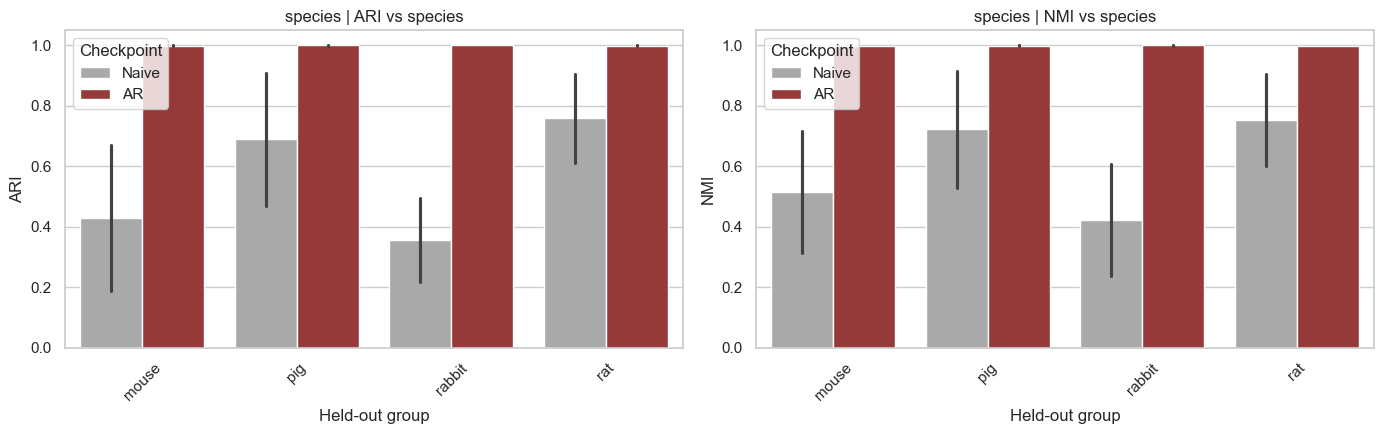

Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/pbmc_ari_nmi_by_heldout.png


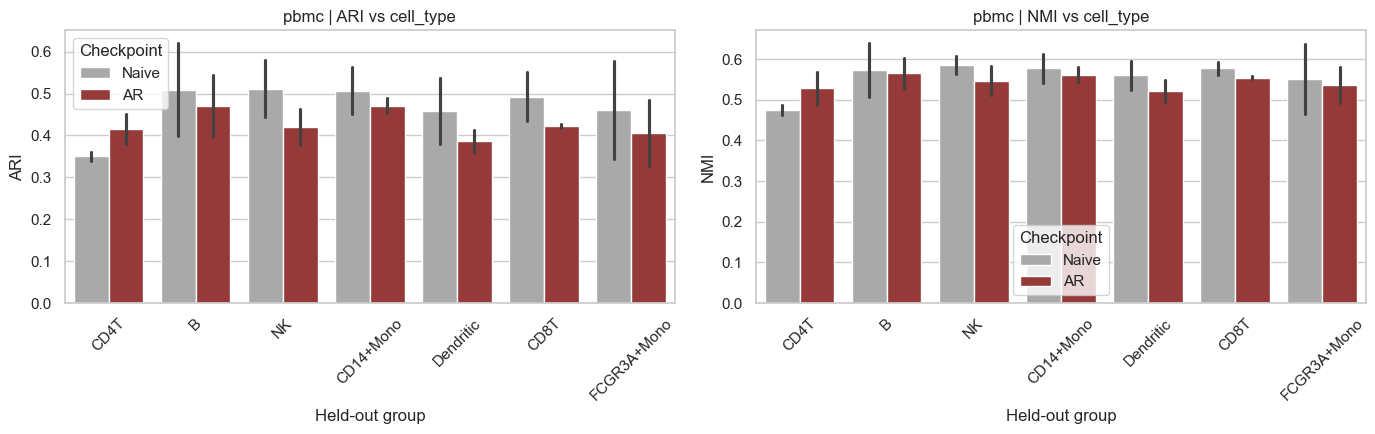

Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/lps-hpoly_ari_nmi_by_heldout.png


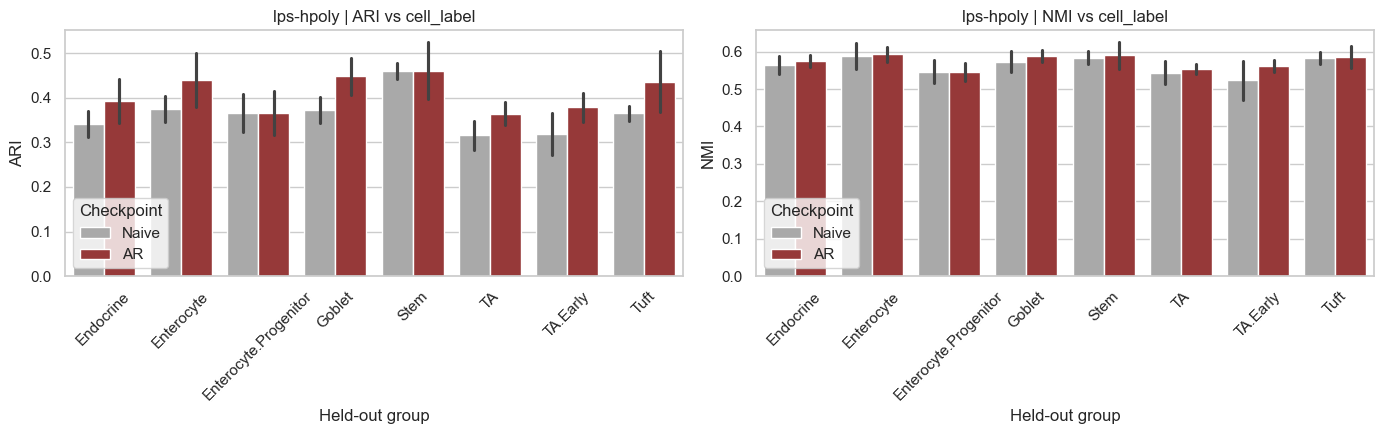

In [21]:
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Naive": "darkgray", "AR": "brown"}

for ds in DATASETS:
    sub = raw[raw["dataset"] == ds].copy()
    label = sub["ground_truth_label"].iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
    for ax, metric, title in zip(
        axes,
        ["ari", "nmi"],
        ["ARI", "NMI"],
    ):
        sns.barplot(
            data=sub,
            x="test",
            y=metric,
            hue="model",
            hue_order=["Naive", "AR"],
            palette=PALETTE,
            errorbar="sd",
            ax=ax,
        )
        ax.set_title(f"{ds} | {title} vs {label}")
        ax.set_xlabel("Held-out group")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="Checkpoint", loc="best")
    fig.tight_layout()
    fig_path = OUT_DIR / f"{ds}_ari_nmi_by_heldout.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

## Compact LaTeX-ready ARI/NMI table (mean over seeds)

In [22]:
def to_latex_mean_std(df_sum: pd.DataFrame, metrics=("ari", "nmi")) -> str:
    rows = []
    ordered = df_sum.copy()
    ordered["model"] = pd.Categorical(ordered["model"], categories=["Naive", "AR"], ordered=True)
    ordered = ordered.sort_values(["dataset", "test", "model"])
    for _, r in ordered.iterrows():
        cells = [
            str(r["dataset"]),
            str(r["model"]),
            str(r["test"]).replace("_", "\\_"),
        ]
        for m in metrics:
            mu, sd = r[f"{m}_mean"], r[f"{m}_std"]
            cells.append(f"{mu:.3f} $\\pm$ {sd:.3f}" if pd.notna(sd) else f"{mu:.3f}")
        rows.append(" & ".join(cells) + " \\\\")
    body = "\n".join(rows)
    header = "Dataset & Model & Held-out & " + " & ".join(m.upper() for m in metrics)
    return (
        "\\begin{table}[t]\n\\centering\n"
        "\\caption{Latent-space k-means clustering metrics (mean $\\pm$ std over seeds) "
        "for scGen Naive and AR best checkpoints.}"
        "\\label{tab:scgen_latent_clustering}\n"
        "\\begin{tabular}{lll" + "r" * len(metrics) + "}\n\\toprule\n"
        + header
        + " \\\\\n\\midrule\n"
        + body
        + "\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"
    )


tex = to_latex_mean_std(by_group)
tex_path = OUT_DIR / "clustering_ari_nmi_table.tex"
tex_path.write_text(tex)
print("Saved:", tex_path)
print(tex[:1200], "...")

Saved: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/scgen_latent_clustering_summaries/clustering_ari_nmi_table.tex
\begin{table}[t]
\centering
\caption{Latent-space k-means clustering metrics (mean $\pm$ std over seeds) for scGen Naive and AR best checkpoints.}\label{tab:scgen_latent_clustering}
\begin{tabular}{lllrr}
\toprule
Dataset & Model & Held-out & ARI & NMI \\
\midrule
lps-hpoly & Naive & Endocrine & 0.341 $\pm$ 0.029 & 0.563 $\pm$ 0.024 \\
lps-hpoly & AR & Endocrine & 0.393 $\pm$ 0.049 & 0.576 $\pm$ 0.016 \\
lps-hpoly & Naive & Enterocyte & 0.375 $\pm$ 0.030 & 0.589 $\pm$ 0.035 \\
lps-hpoly & AR & Enterocyte & 0.439 $\pm$ 0.061 & 0.592 $\pm$ 0.019 \\
lps-hpoly & Naive & Enterocyte.Progenitor & 0.366 $\pm$ 0.043 & 0.546 $\pm$ 0.031 \\
lps-hpoly & AR & Enterocyte.Progenitor & 0.366 $\pm$ 0.049 & 0.545 $\pm$ 0.024 \\
lps-hpoly & Naive & Goblet & 0.373 $\pm$ 0.029 & 0.574 $\pm$ 0.029 \\
lps-hpoly & AR & Goblet & 0.448 $\pm$ 0.042 & 0.